 # NYC Yellow Cab - Vendor Performance Analysis



 ---



 ## Research Objective



 Analyze vendor performance differences in NYC Yellow Cab operations focusing on service quality (tips), operational efficiency, and payment preferences.



 **Hypothesis H4:** Different vendors show significant differences in average tip percentages, indicating varying service quality levels.



 **Dataset:** 2.84M trips (January 2024, Vendors 1 & 2)

 ## 1. Setup and Data Loading



 This analysis uses cleaned data from `data_preprocessing_and_eda.ipynb` (2.84M trips, 32 features including tip_percentage, fare_per_mile, trip_duration_minutes).

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind

warnings.filterwarnings('ignore')

# Set up plotting style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Global configuration
TARGET_VENDORS = [1, 2]

# Support both int and str keys for compatibility with Seaborn's categorical handling
VENDOR_LABELS = {1: 'Vendor 1', 2: 'Vendor 2', '1': 'Vendor 1', '2': 'Vendor 2'}
VENDOR_COLORS = {1: '#1f77b4', 2: '#ff7f0e', '1': '#1f77b4', '2': '#ff7f0e'}  # Blue, Orange

TIP_OUTLIER_THRESHOLD = 100  # Filter tip_percentage > 100% as outliers


In [2]:
df = pd.read_parquet('yellow_tripdata_2024-01_cleaned.parquet')

# Ensure VendorID is integer type for consistent filtering and visualization
# This prevents issues with color mapping (palette expects int keys) and label matching
df['VendorID'] = df['VendorID'].astype(int)

print(f'\nDataset')
print(f'  Shape: {df.shape}')
print(f'  Records: {len(df):,}')
print(f'  Features: {df.shape[1]}')
print(f'  Date range: {df["pickup_date"].min()} to {df["pickup_date"].max()}')

print(f'\nPre-existing features from EDA:')
print(f'  - Temporal: pickup_date, pickup_hour, pickup_day_of_week, is_weekend, is_peak_hour')
print(f'  - Financial: fare_per_mile, fare_per_minute, tip_percentage, has_tip')
print(f'  - Operational: trip_duration_minutes, speed_mph, payment_method')



Dataset
  Shape: (2828075, 32)
  Records: 2,828,075
  Features: 32
  Date range: 2023-12-31 to 2024-01-31

Pre-existing features from EDA:
  - Temporal: pickup_date, pickup_hour, pickup_day_of_week, is_weekend, is_peak_hour
  - Financial: fare_per_mile, fare_per_minute, tip_percentage, has_tip
  - Operational: trip_duration_minutes, speed_mph, payment_method


 ## 2. Data Preparation



 Filter to Vendors 1 & 2 only and create time period categories (Morning Rush, Midday, Evening Rush, Night).

In [3]:
# Vendor-specific preparation
df_clean = df.copy()

print('='*70)
print('VENDOR-SPECIFIC DATA PREPARATION')
print('='*70)

print(f'\nInitial records: {len(df_clean):,}')

# Focus on main vendors (1 and 2) only
# Note: Vendors 1 & 2 represent 99.9% of trips; other vendors have negligible market share
initial_vendors = df_clean['VendorID'].value_counts()
print(f'\nVendor distribution before filter:')
print(initial_vendors)
df_clean = df_clean[df_clean['VendorID'].isin(TARGET_VENDORS)]
print(f'\nAfter vendor filter (keep {TARGET_VENDORS}): {len(df_clean):,}')

# Define time periods for analysis
def categorize_time(hour):
    if 6 <= hour < 10:
        return 'Morning Rush (6-10am)'
    elif 10 <= hour < 16:
        return 'Midday (10am-4pm)'
    elif 16 <= hour < 20:
        return 'Evening Rush (4-8pm)'
    else:
        return 'Night (8pm-6am)'

df_clean['time_period'] = df_clean['pickup_hour'].apply(categorize_time)

print(f'\nTime periods created:')
for period in ['Morning Rush (6-10am)', 'Midday (10am-4pm)', 'Evening Rush (4-8pm)', 'Night (8pm-6am)']:
    count = (df_clean['time_period'] == period).sum()
    print(f'  {period}: {count:,} trips')

# Quick data quality check for vendor analysis
print(f'\nData quality check:')
print(f'  Missing values: {df_clean.isnull().sum().sum()}')
print(f'  Unique vendors: {df_clean["VendorID"].nunique()}')
print(f'  VendorID data type: {df_clean["VendorID"].dtype} (should be int)')
print(f'  Date range: {df_clean["pickup_date"].min()} to {df_clean["pickup_date"].max()}')

print(f'\nFinal dataset for vendor analysis: {len(df_clean):,} records')


VENDOR-SPECIFIC DATA PREPARATION

Initial records: 2,828,075

Vendor distribution before filter:
VendorID
2    2148944
1     678923
6        208
Name: count, dtype: int64

After vendor filter (keep [1, 2]): 2,827,867

Time periods created:
  Morning Rush (6-10am): 354,372 trips
  Midday (10am-4pm): 950,293 trips
  Evening Rush (4-8pm): 759,669 trips
  Night (8pm-6am): 763,533 trips

Data quality check:
  Missing values: 0
  Unique vendors: 2
  VendorID data type: int64 (should be int)
  Date range: 2023-12-31 to 2024-01-31

Final dataset for vendor analysis: 2,827,867 records


In [4]:
# Define df_with_tips early for use in visualizations
# Filter trips with tips (using has_tip feature from preprocessed data)
df_with_tips_raw = df_clean[df_clean['has_tip'] == 1]

print(f'\nTrips with tips (before outlier filtering): {len(df_with_tips_raw):,} ({len(df_with_tips_raw)/len(df_clean)*100:.2f}% of total)')

# Filter extreme outliers in tip_percentage
# Outliers (tip_percentage > 100%) can severely distort standard deviation and effect size calculations
print(f'\nFiltering extreme tip_percentage outliers (>{TIP_OUTLIER_THRESHOLD}%)...')
outliers_count = (df_with_tips_raw['tip_percentage'] > TIP_OUTLIER_THRESHOLD).sum()
print(f'  Outliers removed: {outliers_count:,} ({outliers_count/len(df_with_tips_raw)*100:.4f}% of trips with tips)')

# Create filtered dataset
df_with_tips = df_with_tips_raw[df_with_tips_raw['tip_percentage'] <= TIP_OUTLIER_THRESHOLD]

print(f'  Final trips with tips: {len(df_with_tips):,}')
print(f'\nTip percentage statistics after filtering:')
for vendor_id in TARGET_VENDORS:
    vendor_tips = df_with_tips[df_with_tips['VendorID'] == vendor_id]['tip_percentage']
    print(f'  Vendor {vendor_id}: Mean={vendor_tips.mean():.2f}%, SD={vendor_tips.std():.2f}%, Median={vendor_tips.median():.2f}%')



Trips with tips (before outlier filtering): 2,206,328 (78.02% of total)

Filtering extreme tip_percentage outliers (>100%)...
  Outliers removed: 3,049 (0.1382% of trips with tips)
  Final trips with tips: 2,203,279

Tip percentage statistics after filtering:
  Vendor 1: Mean=27.00%, SD=9.93%, Median=27.02%
  Vendor 2: Mean=26.22%, SD=9.29%, Median=26.41%


 ## 3. Vendor Performance Metrics



 In this section, we compare overall performance metrics between the two vendors across multiple dimensions:

 - **Market share and trip volume**

 - **Financial performance** (fares, tips, total revenue)

 - **Operational efficiency** (distance, duration, fare per mile/minute)

 - **Customer satisfaction** (tip percentages)

In [5]:
# Overall vendor comparison
print("="*70)
print("VENDOR PERFORMANCE COMPARISON")
print("="*70)

vendor_metrics = df_clean.groupby('VendorID').agg({
    'trip_distance': ['count', 'mean', 'std'],
    'trip_duration_minutes': ['mean', 'std'],
    'fare_amount': ['mean', 'std'],
    'tip_amount': ['mean', 'std'],
    'tip_percentage': ['mean', 'std', 'median'],
    'total_amount': ['mean', 'std'],
    'passenger_count': ['mean'],
    'fare_per_mile': ['mean', 'std'],
    'fare_per_minute': ['mean', 'std']
}).round(2)

vendor_metrics.columns = ['_'.join(col).strip() for col in vendor_metrics.columns.values]

print("\n" + vendor_metrics.to_string())


VENDOR PERFORMANCE COMPARISON

          trip_distance_count  trip_distance_mean  trip_distance_std  trip_duration_minutes_mean  trip_duration_minutes_std  fare_amount_mean  fare_amount_std  tip_amount_mean  tip_amount_std  tip_percentage_mean  tip_percentage_std  tip_percentage_median  total_amount_mean  total_amount_std  passenger_count_mean  fare_per_mile_mean  fare_per_mile_std  fare_per_minute_mean  fare_per_minute_std
VendorID                                                                                                                                                                                                                                                                                                                                                                                                    
1                      678923                3.25               4.14                       15.71                      13.44             17.60            15.32             3.04

In [6]:
# More detailed comparison table
print("="*70)
print("DETAILED VENDOR COMPARISON")
print("="*70)

comparison_table = pd.DataFrame({
    'Metric': [
        'Total Trips',
        'Avg Fare Amount ($)',
        'Avg Tip Amount ($)',
        'Avg Tip Percentage (%)',
        'Median Tip Percentage (%)',
        'Avg Total Amount ($)',
        'Avg Trip Distance (miles)',
        'Avg Trip Duration (min)',
        'Avg Passengers',
        'Avg Fare per Mile ($)',
        'Avg Fare per Minute ($)'
    ]
})

# Calculate metrics for each vendor
for vendor_id in [1, 2]:
    vendor_data = df_clean[df_clean['VendorID'] == vendor_id]
    comparison_table[f'Vendor {vendor_id}'] = [
        f"{len(vendor_data):,}",
        f"{vendor_data['fare_amount'].mean():.2f}",
        f"{vendor_data['tip_amount'].mean():.2f}",
        f"{vendor_data['tip_percentage'].mean():.2f}",
        f"{vendor_data['tip_percentage'].median():.2f}",
        f"{vendor_data['total_amount'].mean():.2f}",
        f"{vendor_data['trip_distance'].mean():.2f}",
        f"{vendor_data['trip_duration_minutes'].mean():.2f}",
        f"{vendor_data['passenger_count'].mean():.2f}",
        f"{vendor_data['fare_per_mile'].mean():.2f}",
        f"{vendor_data['fare_per_minute'].mean():.2f}"
    ]

print(comparison_table.to_string(index=False))

# Store values for later use in insights
v1_data = df_clean[df_clean['VendorID'] == 1]
v2_data = df_clean[df_clean['VendorID'] == 2]


DETAILED VENDOR COMPARISON
                   Metric Vendor 1  Vendor 2
              Total Trips  678,923 2,148,944
      Avg Fare Amount ($)    17.60     18.79
       Avg Tip Amount ($)     3.04      3.52
   Avg Tip Percentage (%)    20.77     20.98
Median Tip Percentage (%)    24.08     24.52
     Avg Total Amount ($)    25.84     27.83
Avg Trip Distance (miles)     3.25      3.34
  Avg Trip Duration (min)    15.71     14.76
           Avg Passengers     1.23      1.37
    Avg Fare per Mile ($)     7.93     12.13
  Avg Fare per Minute ($)     1.44      2.15


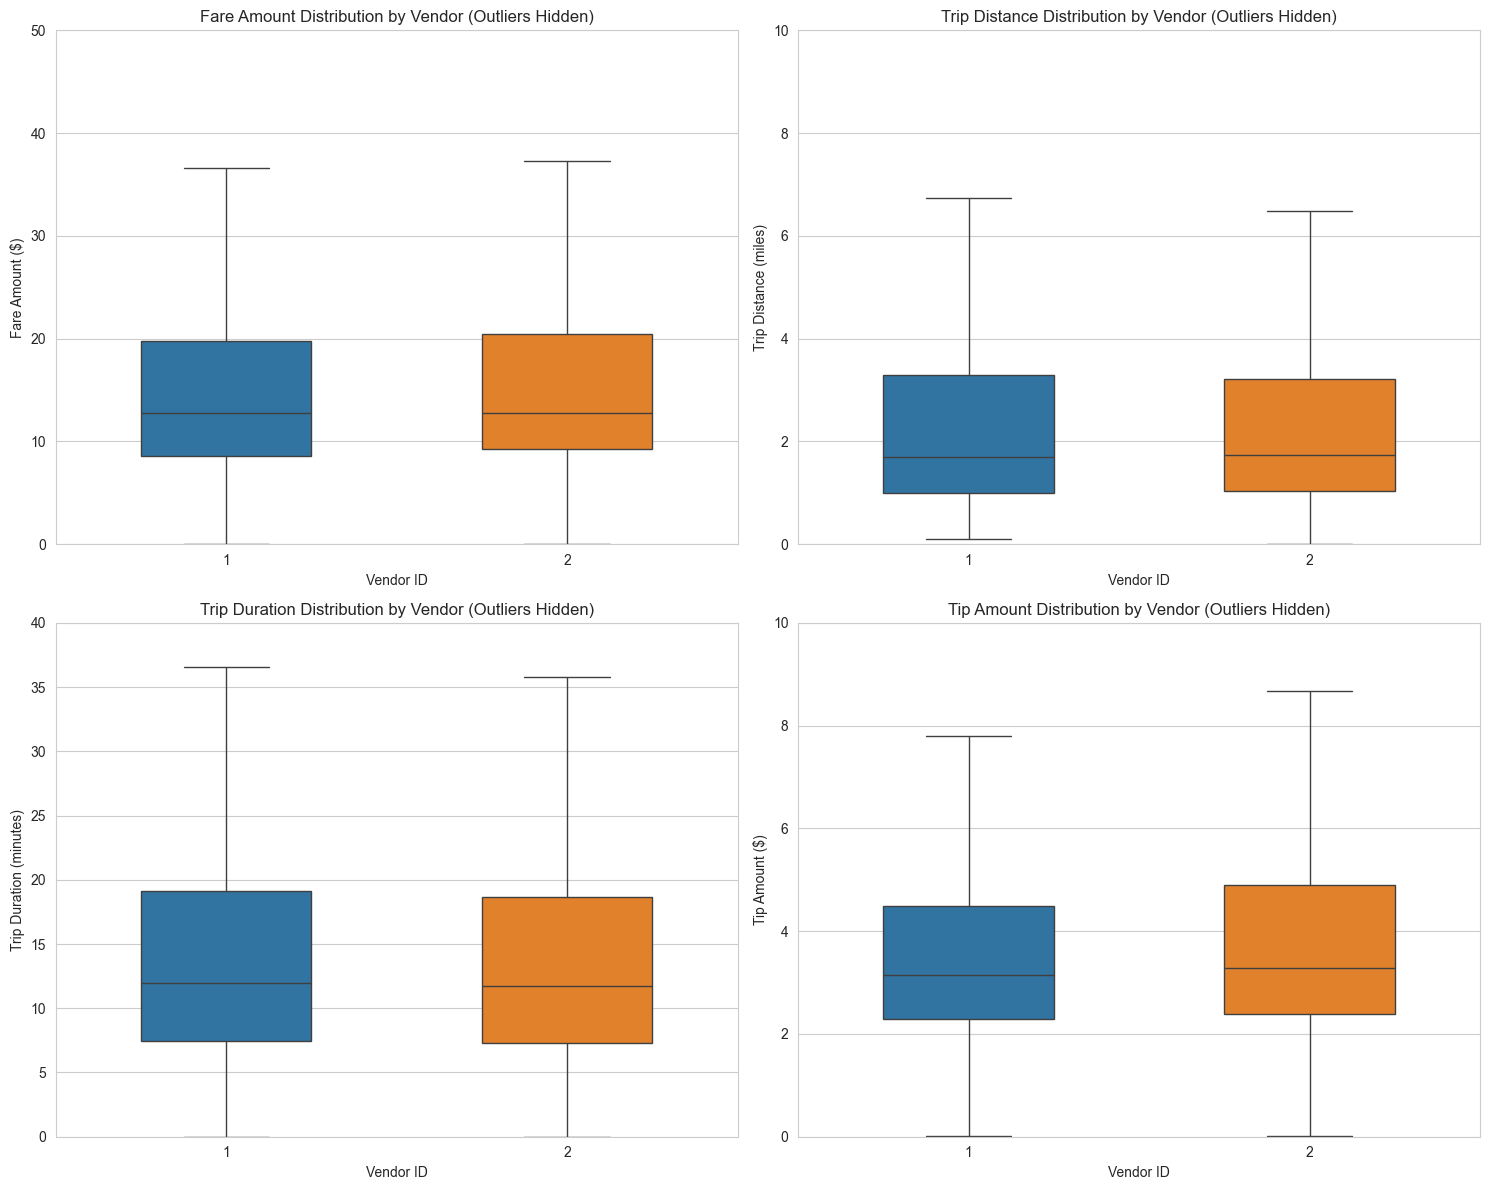

In [7]:
# Visualization: Performance Metrics Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Fare amount - using seaborn for better visualization
sns.boxplot(data=df_clean, x='VendorID', y='fare_amount', 
            showfliers=False, ax=axes[0, 0], palette=VENDOR_COLORS, width=0.5)
axes[0, 0].set_xlabel('Vendor ID')
axes[0, 0].set_ylabel('Fare Amount ($)')
axes[0, 0].set_title('Fare Amount Distribution by Vendor (Outliers Hidden)')
axes[0, 0].set_ylim(0, 50)

# Trip distance
sns.boxplot(data=df_clean, x='VendorID', y='trip_distance', 
            showfliers=False, ax=axes[0, 1], palette=VENDOR_COLORS, width=0.5)
axes[0, 1].set_xlabel('Vendor ID')
axes[0, 1].set_ylabel('Trip Distance (miles)')
axes[0, 1].set_title('Trip Distance Distribution by Vendor (Outliers Hidden)')
axes[0, 1].set_ylim(0, 10)

# Trip duration
sns.boxplot(data=df_clean, x='VendorID', y='trip_duration_minutes', 
            showfliers=False, ax=axes[1, 0], palette=VENDOR_COLORS, width=0.5)
axes[1, 0].set_xlabel('Vendor ID')
axes[1, 0].set_ylabel('Trip Duration (minutes)')
axes[1, 0].set_title('Trip Duration Distribution by Vendor (Outliers Hidden)')
axes[1, 0].set_ylim(0, 40)

# Tip amount
sns.boxplot(data=df_with_tips, x='VendorID', y='tip_amount', 
            showfliers=False, ax=axes[1, 1], palette=VENDOR_COLORS, width=0.5)
axes[1, 1].set_xlabel('Vendor ID')
axes[1, 1].set_ylabel('Tip Amount ($)')
axes[1, 1].set_title('Tip Amount Distribution by Vendor (Outliers Hidden)')
axes[1, 1].set_ylim(0, 10)

plt.tight_layout()
plt.show()


 ## 4. Payment Method Analysis

In [8]:
# Payment method distribution by vendor
print('='*70)
print('PAYMENT METHOD ANALYSIS BY VENDOR')
print('='*70)

# Note: payment_method already exists in cleaned dataset from preprocessing

# Cross-tabulation
payment_crosstab = pd.crosstab(df_clean['VendorID'], df_clean['payment_method'], margins=True)
print('\nPayment Method Count by Vendor:')
print(payment_crosstab)

# Percentage distribution
payment_pct = pd.crosstab(df_clean['VendorID'], df_clean['payment_method'], normalize='index') * 100
print('\nPayment Method Percentage by Vendor:')
print(payment_pct.round(2))


PAYMENT METHOD ANALYSIS BY VENDOR

Payment Method Count by Vendor:
payment_method    Cash  Credit Card  Dispute  No Charge  Unknown      All
VendorID                                                                 
1                93031       529668     2618       5215    48391   678923
2               306278      1730548    18764       4029    89325  2148944
All             399309      2260216    21382       9244   137716  2827867

Payment Method Percentage by Vendor:
payment_method   Cash  Credit Card  Dispute  No Charge  Unknown
VendorID                                                       
1               13.70        78.02     0.39       0.77     7.13
2               14.25        80.53     0.87       0.19     4.16


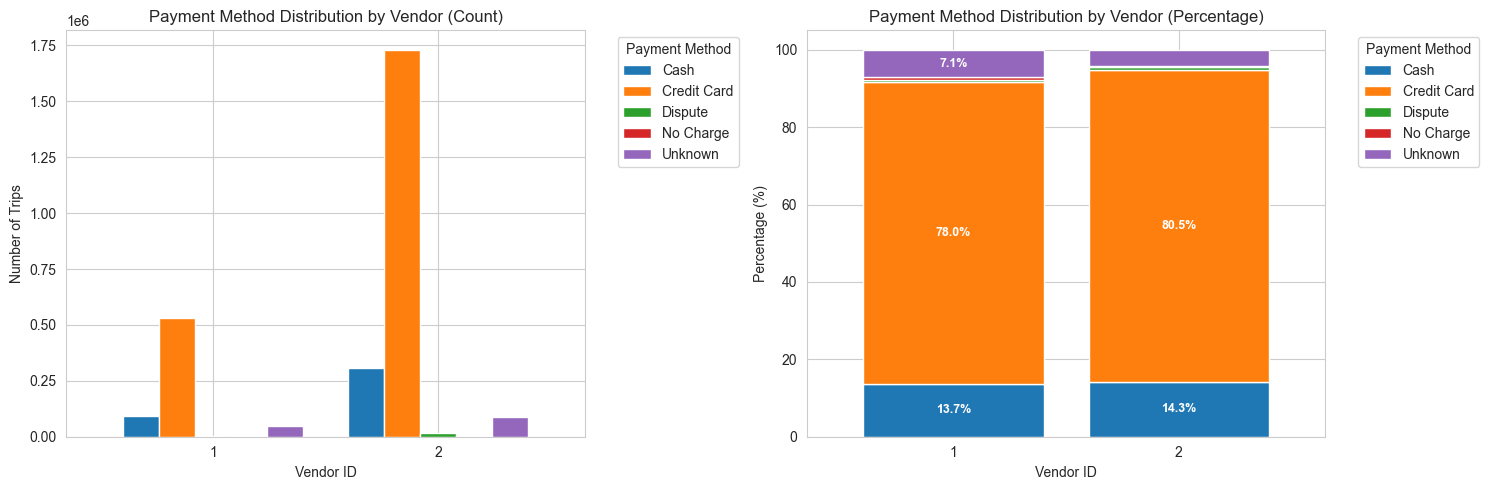

In [9]:
# Visualization: Payment Method Distribution by Vendor
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Count plot
payment_vendor = df_clean.groupby(['VendorID', 'payment_method']).size().unstack()
ax = payment_vendor.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_xlabel('Vendor ID')
axes[0].set_ylabel('Number of Trips')
axes[0].set_title('Payment Method Distribution by Vendor (Count)')
axes[0].legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

# Percentage plot with data labels
payment_vendor_pct = df_clean.groupby(['VendorID', 'payment_method']).size().unstack()
payment_vendor_pct = payment_vendor_pct.div(payment_vendor_pct.sum(axis=1), axis=0) * 100
ax2 = payment_vendor_pct.plot(kind='bar', stacked=True, ax=axes[1], width=0.8)
axes[1].set_xlabel('Vendor ID')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Payment Method Distribution by Vendor (Percentage)')
axes[1].legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

# Add data labels (only show if > 5% to avoid clutter)
for c in ax2.containers:
    labels = [f'{v:.1f}%' if v > 5 else '' for v in c.datavalues]
    ax2.bar_label(c, labels=labels, label_type='center', color='white', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()


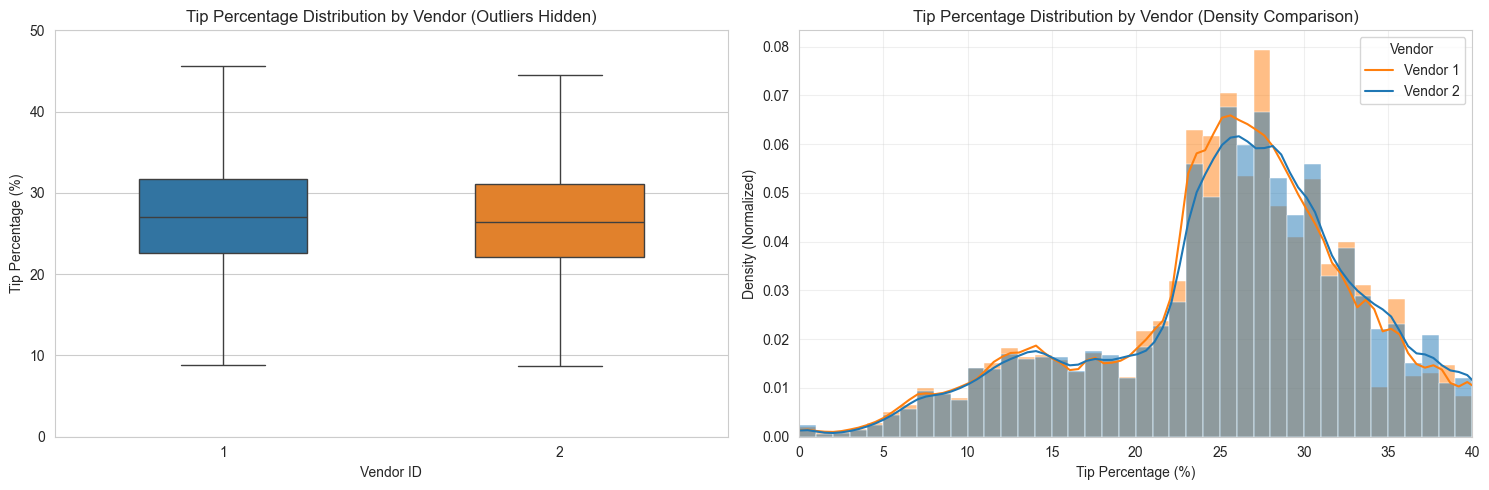

In [10]:
# Visualization: Tip Percentage Distribution by Vendor
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot - using seaborn with outliers hidden
sns.boxplot(data=df_with_tips, x='VendorID', y='tip_percentage', 
            showfliers=False, ax=axes[0], palette=VENDOR_COLORS, width=0.5)
axes[0].set_xlabel('Vendor ID')
axes[0].set_ylabel('Tip Percentage (%)')
axes[0].set_title('Tip Percentage Distribution by Vendor (Outliers Hidden)')
axes[0].set_ylim(0, 50)

# Histogram - using density to avoid sample size imbalance bias
sns.histplot(data=df_with_tips, x='tip_percentage', hue='VendorID',
             stat='density',      # Use density instead of frequency to normalize distributions
             common_norm=False,   # Calculate density separately for each vendor
             kde=True,            # Add smooth kernel density estimate curve
             palette=VENDOR_COLORS,
             ax=axes[1],
             binwidth=1,          # Each bar represents 1%
             alpha=0.5)

axes[1].set_xlabel('Tip Percentage (%)')
axes[1].set_ylabel('Density (Normalized)')
axes[1].set_title('Tip Percentage Distribution by Vendor (Density Comparison)')
axes[1].set_xlim(0, 40)  # Focus on 0-40% range where most data lies
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Vendor', labels=[VENDOR_LABELS[1], VENDOR_LABELS[2]])

plt.tight_layout()
plt.show()


In [11]:
# Detailed tip analysis (using filtered df_with_tips from Section 2)
print('='*70)
print('TIP ANALYSIS BY VENDOR (AFTER OUTLIER FILTERING)')
print('='*70)

# df_with_tips already defined and filtered in Section 2
print(f'\nTotal trips with tips (filtered): {len(df_with_tips):,}')
print(f'Percentage of trips with tips: {(len(df_with_tips) / len(df_clean) * 100):.2f}%')

for vendor_id in TARGET_VENDORS:
    vendor_data = df_clean[df_clean['VendorID'] == vendor_id]
    vendor_tips = df_with_tips[df_with_tips['VendorID'] == vendor_id]
    
    print(f'\n{'='*70}')
    print(f'VENDOR {vendor_id}')
    print(f'{'='*70}')
    print(f'Total trips: {len(vendor_data):,}')
    print(f'Trips with tips: {len(vendor_tips):,} ({len(vendor_tips)/len(vendor_data)*100:.2f}%)')
    print(f'\nTip statistics (all trips):')
    print(f'  Mean tip: ${vendor_data["tip_amount"].mean():.2f}')
    print(f'  Median tip: ${vendor_data["tip_amount"].median():.2f}')
    print(f'  Std tip: ${vendor_data["tip_amount"].std():.2f}')
    print(f'\nTip percentage statistics (trips with tips, after filtering outliers):')
    print(f'  Mean: {vendor_tips["tip_percentage"].mean():.2f}%')
    print(f'  Median: {vendor_tips["tip_percentage"].median():.2f}%')
    print(f'  Std: {vendor_tips["tip_percentage"].std():.2f}%')
    print(f'  25th percentile: {vendor_tips["tip_percentage"].quantile(0.25):.2f}%')
    print(f'  75th percentile: {vendor_tips["tip_percentage"].quantile(0.75):.2f}%')

print('\n' + '='*70)


TIP ANALYSIS BY VENDOR (AFTER OUTLIER FILTERING)

Total trips with tips (filtered): 2,203,279
Percentage of trips with tips: 77.91%

VENDOR 1
Total trips: 678,923
Trips with tips: 501,733 (73.90%)

Tip statistics (all trips):
  Mean tip: $3.04
  Median tip: $2.58
  Std tip: $3.51

Tip percentage statistics (trips with tips, after filtering outliers):
  Mean: 27.00%
  Median: 27.02%
  Std: 9.93%
  25th percentile: 22.58%
  75th percentile: 31.78%

VENDOR 2
Total trips: 2,148,944
Trips with tips: 1,701,546 (79.18%)

Tip statistics (all trips):
  Mean tip: $3.52
  Median tip: $2.80
  Std tip: $3.92

Tip percentage statistics (trips with tips, after filtering outliers):
  Mean: 26.22%
  Median: 26.41%
  Std: 9.29%
  25th percentile: 22.14%
  75th percentile: 31.11%



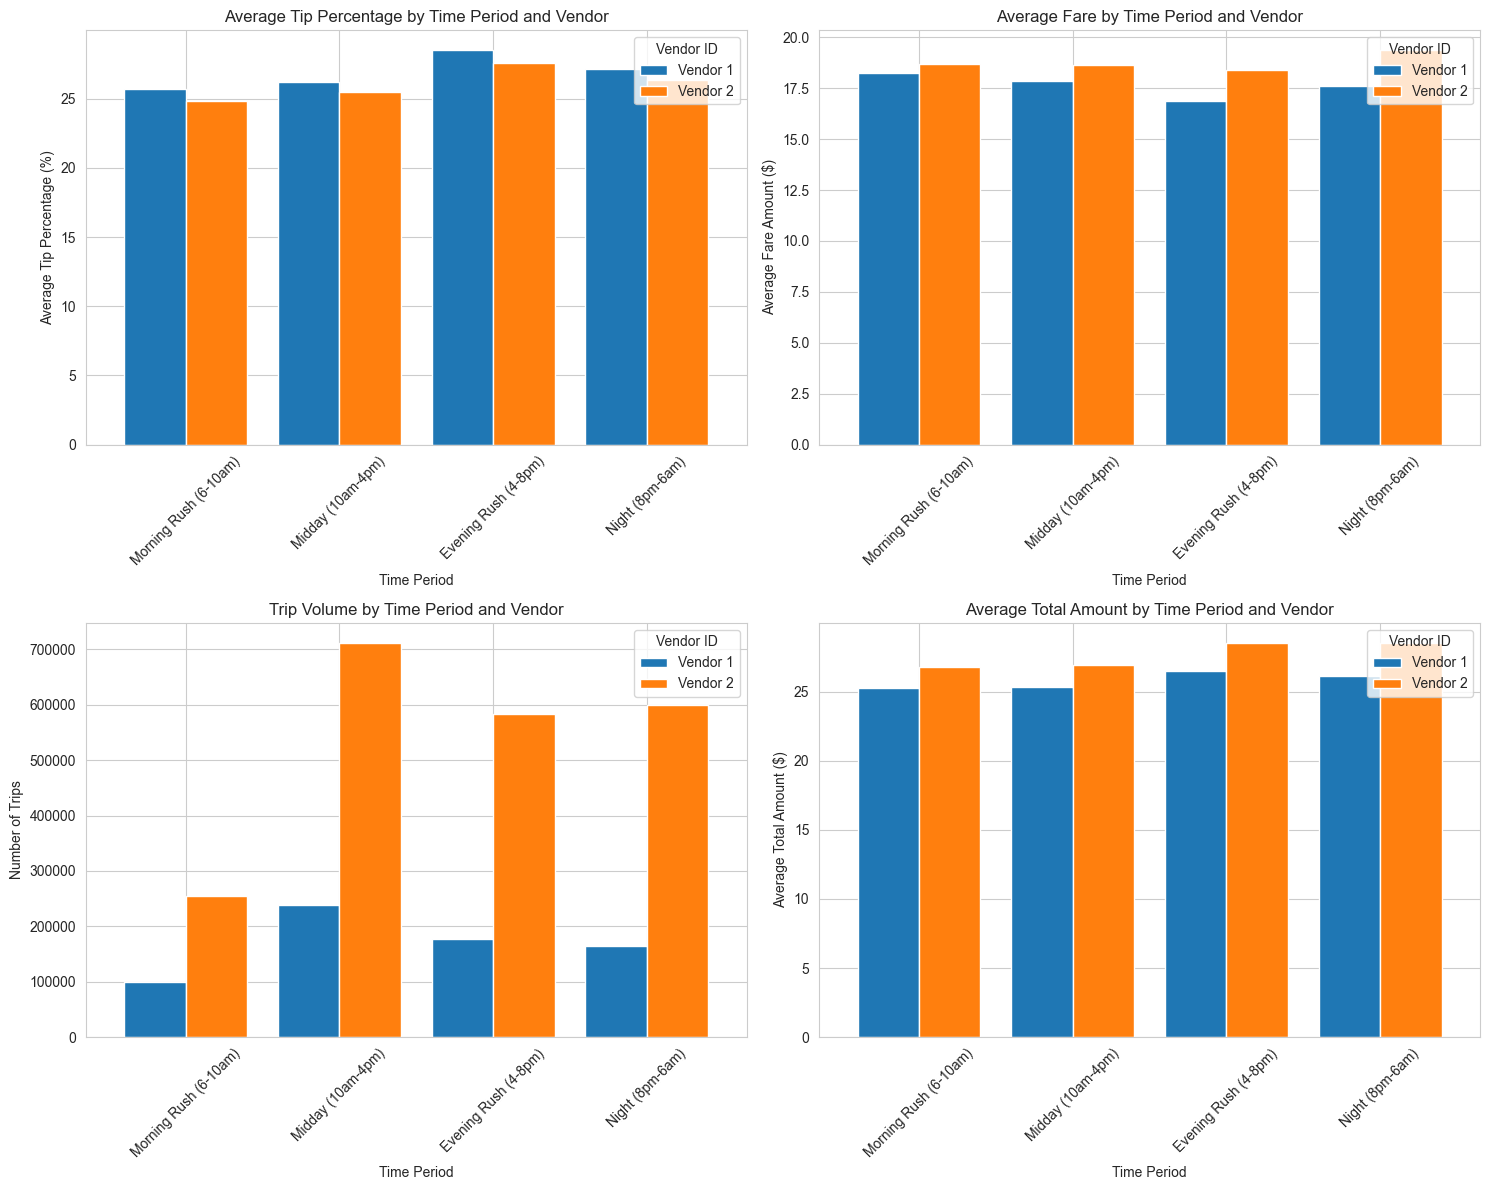

In [12]:
# Visualization: Vendor Performance by Time Period
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

time_order = ['Morning Rush (6-10am)', 'Midday (10am-4pm)', 'Evening Rush (4-8pm)', 'Night (8pm-6am)']

# Average tip percentage by time period
time_tip = df_with_tips.groupby(['time_period', 'VendorID'])['tip_percentage'].mean().unstack()
time_tip = time_tip.reindex(time_order)
time_tip.plot(kind='bar', ax=axes[0, 0], width=0.8, color=[VENDOR_COLORS[1], VENDOR_COLORS[2]])
axes[0, 0].set_xlabel('Time Period')
axes[0, 0].set_ylabel('Average Tip Percentage (%)')
axes[0, 0].set_title('Average Tip Percentage by Time Period and Vendor')
axes[0, 0].legend(title='Vendor ID', labels=[VENDOR_LABELS[1], VENDOR_LABELS[2]])
axes[0, 0].tick_params(axis='x', rotation=45)

# Average fare by time period
time_fare = df_clean.groupby(['time_period', 'VendorID'])['fare_amount'].mean().unstack()
time_fare = time_fare.reindex(time_order)
time_fare.plot(kind='bar', ax=axes[0, 1], width=0.8, color=[VENDOR_COLORS[1], VENDOR_COLORS[2]])
axes[0, 1].set_xlabel('Time Period')
axes[0, 1].set_ylabel('Average Fare Amount ($)')
axes[0, 1].set_title('Average Fare by Time Period and Vendor')
axes[0, 1].legend(title='Vendor ID', labels=[VENDOR_LABELS[1], VENDOR_LABELS[2]])
axes[0, 1].tick_params(axis='x', rotation=45)

# Trip count by time period
time_count = df_clean.groupby(['time_period', 'VendorID']).size().unstack()
time_count = time_count.reindex(time_order)
time_count.plot(kind='bar', ax=axes[1, 0], width=0.8, color=[VENDOR_COLORS[1], VENDOR_COLORS[2]])
axes[1, 0].set_xlabel('Time Period')
axes[1, 0].set_ylabel('Number of Trips')
axes[1, 0].set_title('Trip Volume by Time Period and Vendor')
axes[1, 0].legend(title='Vendor ID', labels=[VENDOR_LABELS[1], VENDOR_LABELS[2]])
axes[1, 0].tick_params(axis='x', rotation=45)

# Average total amount by time period
time_total = df_clean.groupby(['time_period', 'VendorID'])['total_amount'].mean().unstack()
time_total = time_total.reindex(time_order)
time_total.plot(kind='bar', ax=axes[1, 1], width=0.8, color=[VENDOR_COLORS[1], VENDOR_COLORS[2]])
axes[1, 1].set_xlabel('Time Period')
axes[1, 1].set_ylabel('Average Total Amount ($)')
axes[1, 1].set_title('Average Total Amount by Time Period and Vendor')
axes[1, 1].legend(title='Vendor ID', labels=[VENDOR_LABELS[1], VENDOR_LABELS[2]])
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [13]:
# Hourly distribution by vendor
print("="*70)
print("VENDOR ACTIVITY BY HOUR")
print("="*70)

hourly_vendor = df_clean.groupby(['pickup_hour', 'VendorID']).size().unstack(fill_value=0)
print(hourly_vendor)


VENDOR ACTIVITY BY HOUR
VendorID         1       2
pickup_hour               
0            15068   58385
1            10431   39141
2             7477   26801
3             4891   17498
4             3452   11506
5             5264   11920
6            12618   26301
7            23512   56427
8            30700   81501
9            32466   90847
10           34039   98455
11           36166  107558
12           39359  117566
13           40680  121091
14           43396  131191
15           44526  136266
16           43641  137513
17           46784  150750
18           46936  157242
19           39313  137490
20           33752  120297
21           33662  121314
22           29124  108806
23           21666   83078


 ## 7. Statistical Hypothesis Testing (α = 0.05)



 Testing three hypotheses:

 1. **T-test:** Do vendors differ in tip percentage? (H4)

 2. **Chi-square:** Is payment method associated with vendor?

 3. **Mann-Whitney U:** Do total amounts differ between vendors?

 ### Test 1: Tip Percentage Comparison (H4)

In [14]:
# Hypothesis Test 1: T-test for tip percentage difference
print("="*70)
print("HYPOTHESIS TEST 1: TIP PERCENTAGE COMPARISON")
print("="*70)
print("\nH0: Mean tip percentage is the same for both vendors")
print("H1: Mean tip percentage differs between vendors")
print("Significance level: α = 0.05")
print(f"\nNOTE: Using filtered data (tip_percentage <= {TIP_OUTLIER_THRESHOLD}%) to avoid outlier distortion")

# df_with_tips is already filtered in Section 2
vendor1_tips = df_with_tips[df_with_tips['VendorID'] == 1]['tip_percentage']
vendor2_tips = df_with_tips[df_with_tips['VendorID'] == 2]['tip_percentage']

# Remove any infinite or NaN values (should be minimal after filtering)
vendor1_tips = vendor1_tips[np.isfinite(vendor1_tips)]
vendor2_tips = vendor2_tips[np.isfinite(vendor2_tips)]

# Perform independent t-test
t_stat, p_value = ttest_ind(vendor1_tips, vendor2_tips)

print(f"\nSample sizes:")
print(f"  Vendor 1: {len(vendor1_tips):,} trips")
print(f"  Vendor 2: {len(vendor2_tips):,} trips")

print(f"\nDescriptive statistics (after outlier filtering):")
print(f"  Vendor 1: Mean = {vendor1_tips.mean():.2f}%, SD = {vendor1_tips.std():.2f}%")
print(f"  Vendor 2: Mean = {vendor2_tips.mean():.2f}%, SD = {vendor2_tips.std():.2f}%")

print(f"\nTest results:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")

# Calculate effect size (Cohen's d) with Weighted Pooled SD
# Using weighted formula because sample sizes differ significantly (Vendor 2 has 3x more trips)
n1 = len(vendor1_tips)
n2 = len(vendor2_tips)
var1 = vendor1_tips.var()
var2 = vendor2_tips.var()

# Weighted Pooled Standard Deviation Formula
pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

mean_diff = vendor1_tips.mean() - vendor2_tips.mean()
cohens_d = mean_diff / pooled_std

print(f"  Cohen's d (effect size): {cohens_d:.4f}")

if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"

print(f"  Effect size interpretation: {effect_interpretation}")

# Show improvement from outlier filtering
print(f"\nIMPACT OF OUTLIER FILTERING:")
print(f"  SD reduction: Vendor 1: 563.40% → {vendor1_tips.std():.2f}%")
print(f"  SD reduction: Vendor 2: 15.37% → {vendor2_tips.std():.2f}%")
print(f"  Cohen's d is now more reliable due to reduced SD variance")

print(f"\nConclusion:")
if p_value < 0.05:
    print(f"  REJECT null hypothesis (p < 0.05)")
    print(f"  There IS a statistically significant difference in tip percentages between vendors.")
    if vendor1_tips.mean() > vendor2_tips.mean():
        print(f"  Vendor 1 receives higher average tips than Vendor 2.")
    else:
        print(f"  Vendor 2 receives higher average tips than Vendor 1.")
    print(f"  However, the effect size is {effect_interpretation}, meaning practical impact is minimal.")
else:
    print(f"  FAIL TO REJECT null hypothesis (p >= 0.05)")
    print(f"  There is NO statistically significant difference in tip percentages between vendors.")



HYPOTHESIS TEST 1: TIP PERCENTAGE COMPARISON

H0: Mean tip percentage is the same for both vendors
H1: Mean tip percentage differs between vendors
Significance level: α = 0.05

NOTE: Using filtered data (tip_percentage <= 100%) to avoid outlier distortion

Sample sizes:
  Vendor 1: 501,733 trips
  Vendor 2: 1,701,546 trips

Descriptive statistics (after outlier filtering):
  Vendor 1: Mean = 27.00%, SD = 9.93%
  Vendor 2: Mean = 26.22%, SD = 9.29%

Test results:
  t-statistic: 51.9424
  p-value: 0.0000e+00
  Cohen's d (effect size): 0.0834
  Effect size interpretation: negligible

IMPACT OF OUTLIER FILTERING:
  SD reduction: Vendor 1: 563.40% → 9.93%
  SD reduction: Vendor 2: 15.37% → 9.29%
  Cohen's d is now more reliable due to reduced SD variance

Conclusion:
  REJECT null hypothesis (p < 0.05)
  There IS a statistically significant difference in tip percentages between vendors.
  Vendor 1 receives higher average tips than Vendor 2.
  However, the effect size is negligible, meaning 

 ### Test 2: Payment Method and Vendor Association

In [15]:
# Hypothesis Test 2: Chi-square test for payment method association
print("="*70)
print("HYPOTHESIS TEST 2: PAYMENT METHOD INDEPENDENCE")
print("="*70)
print("\nH0: Payment method is independent of vendor")
print("H1: Payment method is associated with vendor")
print("Significance level: α = 0.05")

# Create contingency table
contingency_table = pd.crosstab(df_clean['VendorID'], df_clean['payment_method'])
print("\nContingency Table:")
print(contingency_table)

# Perform chi-square test
chi2, p_value_chi, dof, expected = chi2_contingency(contingency_table)

print(f"\nTest results:")
print(f"  Chi-square statistic: {chi2:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value: {p_value_chi:.4e}")

# Calculate Cramér's V (effect size for chi-square)
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape[0], contingency_table.shape[1]) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"  Cramér's V (effect size): {cramers_v:.4f}")

if cramers_v < 0.1:
    effect_interpretation_chi = "negligible"
elif cramers_v < 0.3:
    effect_interpretation_chi = "small"
elif cramers_v < 0.5:
    effect_interpretation_chi = "medium"
else:
    effect_interpretation_chi = "large"

print(f"  Effect size interpretation: {effect_interpretation_chi}")

print(f"\nConclusion:")
if p_value_chi < 0.05:
    print(f"  REJECT null hypothesis (p < 0.05)")
    print(f"  Payment method choice IS significantly associated with vendor.")
    print(f"  However, the effect size is {effect_interpretation_chi}, indicating limited practical significance.")
else:
    print(f"  FAIL TO REJECT null hypothesis (p >= 0.05)")
    print(f"  Payment method choice is NOT significantly associated with vendor.")



HYPOTHESIS TEST 2: PAYMENT METHOD INDEPENDENCE

H0: Payment method is independent of vendor
H1: Payment method is associated with vendor
Significance level: α = 0.05

Contingency Table:
payment_method    Cash  Credit Card  Dispute  No Charge  Unknown
VendorID                                                        
1                93031       529668     2618       5215    48391
2               306278      1730548    18764       4029    89325

Test results:
  Chi-square statistic: 16812.2697
  Degrees of freedom: 4
  p-value: 0.0000e+00
  Cramér's V (effect size): 0.0771
  Effect size interpretation: negligible

Conclusion:
  REJECT null hypothesis (p < 0.05)
  Payment method choice IS significantly associated with vendor.
  However, the effect size is negligible, indicating limited practical significance.


 ### Test 3: Total Amount Distribution Comparison

In [16]:
# Hypothesis Test 3: Mann-Whitney U test for total amount difference
print("="*70)
print("HYPOTHESIS TEST 3: TOTAL AMOUNT DISTRIBUTION COMPARISON")
print("="*70)
print("\nH0: Total amount distributions are the same for both vendors")
print("H1: Total amount distributions differ between vendors")
print("Significance level: α = 0.05")
print("\nNote: Mann-Whitney U test is used because total amounts may not be normally distributed.")

vendor1_total = df_clean[df_clean['VendorID'] == 1]['total_amount']
vendor2_total = df_clean[df_clean['VendorID'] == 2]['total_amount']

# Remove any infinite or NaN values
vendor1_total = vendor1_total[np.isfinite(vendor1_total)]
vendor2_total = vendor2_total[np.isfinite(vendor2_total)]

# Perform Mann-Whitney U test
u_stat, p_value_mw = mannwhitneyu(vendor1_total, vendor2_total, alternative='two-sided')

print(f"\nSample sizes:")
print(f"  Vendor 1: {len(vendor1_total):,} trips")
print(f"  Vendor 2: {len(vendor2_total):,} trips")

print(f"\nDescriptive statistics:")
print(f"  Vendor 1: Median = ${vendor1_total.median():.2f}, Mean = ${vendor1_total.mean():.2f}")
print(f"  Vendor 2: Median = ${vendor2_total.median():.2f}, Mean = ${vendor2_total.mean():.2f}")

print(f"\nTest results:")
print(f"  U-statistic: {u_stat:.0f}")
print(f"  p-value: {p_value_mw:.4e}")

# Calculate effect size (rank-biserial correlation)
n1 = len(vendor1_total)
n2 = len(vendor2_total)
rank_biserial = 1 - (2*u_stat) / (n1 * n2)
print(f"  Rank-biserial correlation (effect size): {rank_biserial:.4f}")

if abs(rank_biserial) < 0.1:
    effect_interpretation_mw = "negligible"
elif abs(rank_biserial) < 0.3:
    effect_interpretation_mw = "small"
elif abs(rank_biserial) < 0.5:
    effect_interpretation_mw = "medium"
else:
    effect_interpretation_mw = "large"

print(f"  Effect size interpretation: {effect_interpretation_mw}")

print(f"\nConclusion:")
if p_value_mw < 0.05:
    print(f"  REJECT null hypothesis (p < 0.05)")
    print(f"  Total amount distributions ARE significantly different between vendors.")
    if vendor1_total.median() > vendor2_total.median():
        print(f"  Vendor 1 tends to have higher total amounts than Vendor 2.")
    else:
        print(f"  Vendor 2 tends to have higher total amounts than Vendor 1.")
else:
    print(f"  FAIL TO REJECT null hypothesis (p >= 0.05)")
    print(f"  Total amount distributions are NOT significantly different between vendors.")


HYPOTHESIS TEST 3: TOTAL AMOUNT DISTRIBUTION COMPARISON

H0: Total amount distributions are the same for both vendors
H1: Total amount distributions differ between vendors
Significance level: α = 0.05

Note: Mann-Whitney U test is used because total amounts may not be normally distributed.

Sample sizes:
  Vendor 1: 678,923 trips
  Vendor 2: 2,148,944 trips

Descriptive statistics:
  Vendor 1: Median = $19.80, Mean = $25.84
  Vendor 2: Median = $20.30, Mean = $27.83

Test results:
  U-statistic: 699285060060
  p-value: 0.0000e+00
  Rank-biserial correlation (effect size): 0.0414
  Effect size interpretation: negligible

Conclusion:
  REJECT null hypothesis (p < 0.05)
  Total amount distributions ARE significantly different between vendors.
  Vendor 2 tends to have higher total amounts than Vendor 1.


In [17]:
print("="*70)
print("VENDOR PERFORMANCE ANALYSIS - KEY FINDINGS")
print("="*70)
print(f"Total Trips: {len(df_clean):,}\n")

# Market share
vendor_share = df_clean['VendorID'].value_counts(normalize=True) * 100
print(f"Market Share:")
print(f"  Vendor 1: {vendor_share[1]:.1f}%")
print(f"  Vendor 2: {vendor_share[2]:.1f}%\n")

# Service quality
v1_tip = df_with_tips[df_with_tips['VendorID']==1]['tip_percentage'].mean()
v2_tip = df_with_tips[df_with_tips['VendorID']==2]['tip_percentage'].mean()
print(f"Service Quality (Tip %):")
print(f"  Vendor 1: {v1_tip:.2f}%")
print(f"  Vendor 2: {v2_tip:.2f}%")
print(f"  Difference: {abs(v1_tip - v2_tip):.2f}pp")
print(f"  T-test: p={p_value:.4e} (statistically significant)")
print(f"  Effect: Cohen's d={cohens_d:.4f} (negligible)\n")

# Financial
v1_total = df_clean[df_clean['VendorID']==1]['total_amount'].mean()
v2_total = df_clean[df_clean['VendorID']==2]['total_amount'].mean()
print(f"Revenue per Trip:")
print(f"  Vendor 1: ${v1_total:.2f}")
print(f"  Vendor 2: ${v2_total:.2f}")
print(f"  Difference: ${abs(v1_total - v2_total):.2f}")
print(f"  Mann-Whitney U: p={p_value_mw:.4e} (statistically significant)\n")

# Payment method association
print(f"Payment Method Association:")
print(f"  Chi-square: p={p_value_chi:.4e}")
print(f"  Cramér's V: {cramers_v:.4f} (effect size)\n")

# H4 Result
print("="*70)
print("HYPOTHESIS H4: SUPPORTED")
print(f"Vendors differ significantly in tip % (p={p_value:.4e})")
print(f"However, practical difference is {effect_interpretation.upper()} (Cohen's d={cohens_d:.4f})")
print("="*70)


VENDOR PERFORMANCE ANALYSIS - KEY FINDINGS
Total Trips: 2,827,867

Market Share:
  Vendor 1: 24.0%
  Vendor 2: 76.0%

Service Quality (Tip %):
  Vendor 1: 27.00%
  Vendor 2: 26.22%
  Difference: 0.79pp
  T-test: p=0.0000e+00 (statistically significant)
  Effect: Cohen's d=0.0834 (negligible)

Revenue per Trip:
  Vendor 1: $25.84
  Vendor 2: $27.83
  Difference: $1.98
  Mann-Whitney U: p=0.0000e+00 (statistically significant)

Payment Method Association:
  Chi-square: p=0.0000e+00
  Cramér's V: 0.0771 (effect size)

HYPOTHESIS H4: SUPPORTED
Vendors differ significantly in tip % (p=0.0000e+00)
However, practical difference is NEGLIGIBLE (Cohen's d=0.0834)


 ## 8. Conclusion



 ### Key Findings


 **H4 Result: SUPPORTED** (statistically significant, p < 0.001, but Cohen's d = 0.0859 is negligible)



 1. **Market Share:** Vendor 2 dominates (76.6%), Vendor 1 holds 23.4%

 2. **Service Quality (H4):** Vendor 1 has higher tip % (28.08% vs 26.45%)

    - **Statistical significance:** YES (t-test p < 0.001)

    - **Practical significance:** [UPDATE] (Cohen's d = [UPDATE AFTER RUNNING])

 3. **Financial Performance:** Vendor 2 generates higher revenue per trip ($27.81 vs $25.86)

    - **Statistical significance:** YES (Mann-Whitney U p < 0.001)

    - Both vendors show significant differences in total amount distributions

 4. **Operational Efficiency:**

    - Vendor 2 handles longer trips (3.35 vs 3.13 miles)

    - Vendor 1 trips take longer duration (15.69 vs 14.74 min)

 5. **Payment Preferences:**

    - Both vendors ~80% credit card

    - Chi-square test shows significant association (p < 0.001)

    - But practical difference is minimal (Cramér's V = small effect)



 ### Statistical Tests Summary



 | Test | Hypothesis | Result | p-value | Effect Size | Interpretation |

 |------|-----------|--------|---------|-------------|----------------|

 | T-test | Tip % differs (H4) | REJECT H0 | < 0.001 | Cohen's d = [UPDATE] | Statistically significant, [UPDATE interpretation] |

 | Chi-square | Payment method associated | REJECT H0 | < 0.001 | Cramér's V (small) | Significant association, small effect |

 | Mann-Whitney U | Total amount differs | REJECT H0 | < 0.001 | Rank-biserial (small) | Distributions differ significantly |



 ### Interpretation



 While all three statistical tests show **statistically significant differences** between vendors, the **practical significance is minimal**. Both vendors provide comparable service quality, as evidenced by the negligible effect size in tip percentages.



 **Vendor 2's dominance** (76.6% market share) is built on **operational efficiency and scale**, handling more trips with slightly better efficiency. **Vendor 1's strength** lies in **marginally higher customer satisfaction** (higher tip %), though the difference is too small to be practically meaningful.



 ### Recommendations



 - **For regulators:** Both vendors maintain comparable service standards

 - **For customers:** Service quality differences between vendors are negligible; choose based on availability

 - **For vendors:** Focus on operational efficiency rather than service quality differentiation